#### Teoría de Circuitos II - UTN.BA

# Tarea Semanal 6
#### Autor: Rodríguez Silvosa, Martín
#### Docentes: LLamedo, Mariano ; Moharos, David

### Consigna:
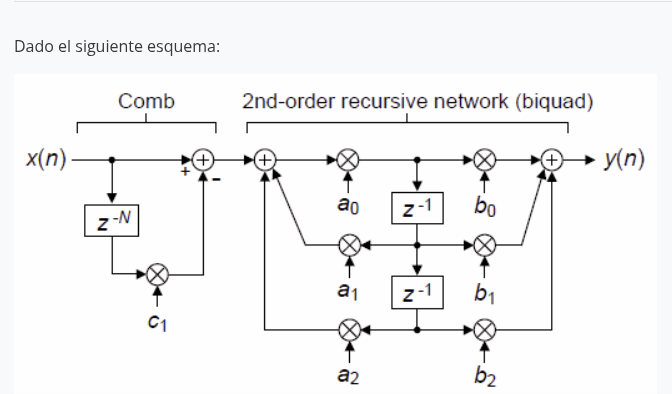
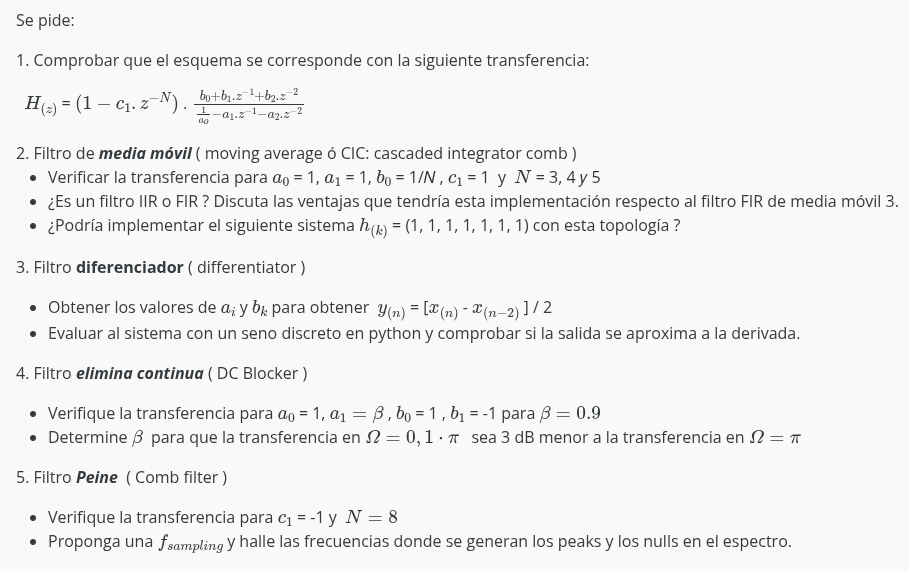
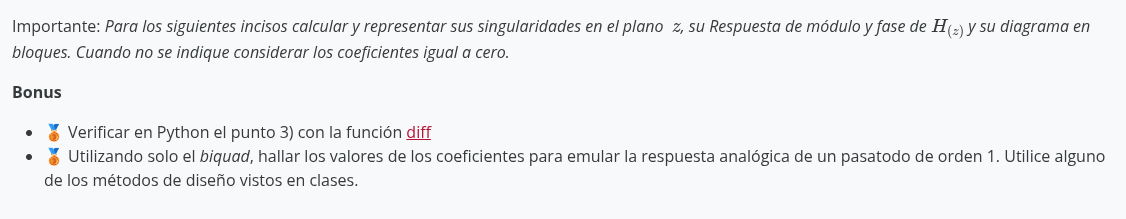

#### Librerías a usar:

In [3]:
import sympy as sp
from pytc2.remociones import remover_polo_dc
from pytc2.general import a_equal_b_latex_s, print_latex, s, symbfunc2tf, factorSOS
from pytc2.sistemas_lineales import bodePlot
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig
import math
from pytc2.sistemas_lineales import analyze_sys

## Sistema DF2 digital:

**Planteo ecuaciones en el dominio de la frecuencia digital:**

$$
\begin{aligned}
k_1 &= X(z) - X(z)\, z^{-N}\,c_1 \quad (1)\\
k_2 &= k_1 + k_5 a_1 + k_6 a_2 \quad (2)\\
k_3 &= k_2\, a_0 \quad (3)\\
k_4 &= k_3\, b_0 \quad (4)\\
k_5 &= k_3\, z^{-1} \quad (5)\\
k_6 &= k_5\, z^{-1} \quad (6)\\
Y(z) &= k_4 + k_5 b_1 + k_6 b_2 \quad (7)
\end{aligned}
$$

**Sustituyo (2) en (3) = (8):**

$$
k_3 = \big[k_1 + k_5 a_1 + k_6 a_2\big]\, a_0 = \big[X(z) - X(z)\, z^{-N}\,c_1 + k_5 a_1 + k_6 a_2\big]\, a_0 \quad (8)
$$

**Sustituyo (5) en (8) = (9):**

$$
k_3 = \big[X(z) - X(z)\,z^{-N} c_1 + k_3\, z^{-1} a_1 + k_6 a_2\big]\, a_0 \quad (9)
$$

**Sustituyo (6) en (9) = (10):**

$$
k_3 = \big[X(z) - X(z)\,z^{-N} c_1 + k_3\, z^{-1} a_1 + k_3\, z^{-2} a_2\big]\, a_0 \quad (10)
$$

**Distribuyo:**

$$
k_3 = X(z)\,a_0 - X(z)\,z^{-N} c_1 a_0 + k_3\, z^{-1} a_1 a_0 + k_3\, z^{-2} a_2 a_0 \quad (11)
$$

**Agrupo términos con $k_3$:**

$$
k_3\big(1 - z^{-1} a_1 a_0 - z^{-2} a_2 a_0\big) = X(z)\,a_0 - X(z)\,z^{-N} c_1 a_0
$$

**Ecuación (11):**

$$
k_3 = \frac{X(z)\,a_0 - X(z)\,z^{-N} c_1 a_0}{1 - z^{-1} a_1 a_0 - z^{-2} a_2 a_0}
= \frac{X(z) - X(z)\,z^{-N} c_1}{\dfrac{1}{a_0} - z^{-1} a_1 - z^{-2} a_2}
$$

**Sustituyo (5), (6) y (4) en (7) = (12):**

$$
Y(z) = k_3 b_0 + k_3\, z^{-1} b_1 + k_3\, z^{-2} b_2 = k_3\big(b_0 + z^{-1} b_1 + z^{-2} b_2\big) \quad (12)
$$

**Sustituyo (11) en (12):**

$$
Y(z) = X(z)\cdot \frac{1 - z^{-N} c_1}{\dfrac{1}{a_0} - z^{-1} a_1 - z^{-2} a_2}\cdot \big(b_0 + z^{-1} b_1 + z^{-2} b_2\big) \quad (13)
$$

**Función de transferencia final:**

$$
H(z) = \frac{Y(z)}{X(z)} = \frac{1 - z^{-N} c_1}{\dfrac{1}{a_0} - z^{-1} a_1 - z^{-2} a_2}\cdot \big(b_0 + z^{-1} b_1 + z^{-2} b_2\big)
$$

### Corroboramos correctamente la transferencia

## Filtro media móvil
#### Reemplazamos sobre la transferencia final $ a_0=a_1=c_1=1$, $ b_0=\frac{1}{N}$, $ N=3,4,5 $

$$
H(z) = \frac{Y(z)}{X(z)}= \frac{1 - z^{-N}}{1 - z^{-1} - z^{-2} a_2}\cdot \big(\frac{1}{N} + z^{-1} b_1 + z^{-2} b_2\big)
$$

$$
Y(z) \cdot (1- z^{-1} - z^{-2}\, a_2) = X(z) \cdot (1 - z^{-N}) \cdot (\frac{1}{N}+z^{-1}\, b_1 + z^{-2}\, b_2)
$$

$$
Y(z) - Y(z)\, z^{-1} - Y(z)\, z^{-2}\, a_2 = (X(z) - X(z)\, z^{-N}) \cdot (\frac{1}{N}+ z^{-1}\, b_1 + z^{-2}\, b_2) 
$$

$$
Y(z) - Y(z)\, z^{-1} - Y(z)\, z^{-2}\, a_2 = X(z)\, \frac{1}{N}+X(z)\, z^{-1}\, b_1 +X(z)\, z^{-2}\, b_2 - X(z)\, z^{-N}\frac{1}{N}- X(z)\, z^{-N} z^{-1}\, b_1 - X(z)\, z^{-N} z^{-2}\, b_2
$$

#### Pasamos al dominio temporal muestreal:

$$
y(n) - y(n-1) - y(n-2)\, a_2 = x(n)\, \frac{1}{N}+x(n-1)\, b_1 +x(n-2)\, b_2 - x(n-N)\frac{1}{N}- x(n-N-1)\, b_1 - x(n-N-2)\, b_2
$$

#### Reemplazando $N=3$ y despejando $y(n)$ nos queda:

$$
y(n) = x(n)\, \frac{1}{3}+x(n-1)\, b_1 +x(n-2)\, b_2 - x(n-3)\frac{1}{3}- x(n-4)\, b_1 - x(n-5)\, b_2  + y(n-1) + y(n-2)\, a_2
$$

**(reemplazar N por 4 o 5 simplemente nos cambia el retraso de los términos afectados y la ponderación)**

### Filtro resultante: Filtro IIR:
#### La sola presencia de los términos con $a_x != a_0$ nos indica que no puede tratarse de un filtro FIR

### Ventajas y desventajas: Típicas de IIR VS FIR:
- Ventajas:
- El sistema IIR es mucho más selectivo y tiene cambios más abruptos con la misma cantidad de coeficientes que un filtro FIR
- Desventajas:
- La fase del sistema IIR, a diferencia del FIR, no es lineal, lo que retrasa de forma distinta diferentes frecuencias
- La presencia de polos vuelve al sistema IIR posiblemente inestable, cosa que un FIR nunca lo será
- Errores en el muestreo pueden ser amplificados indefinidamente por tener retroalimentación, mientras que el FIR es siempre finito

### Sistema $h_{(k)}=(1, 1, 1, 1, 1, 1, 1)$: Filtro FIR media móvil de 7 muestras
#### Su realización es imposible con la topología que tenemos ya que presenta polos y tiene una cantidad de 5 muestras.

### Implementación del filtro, simulación:

#### Para poder simular la transferencia, necesitamos los valores de los parámetros no especificados.
#### Viendo el pie de página de la consigna, se especifica que se contemplen como 0 todo aquel parámetro no especificado
#### Esto cambia la transferencia final, vamos a verificar:

$$
H(z) = \frac{Y(z)}{X(z)}= \frac{1 - z^{-N}}{1 - z^{-1} - z^{-2} \cdot 0}\cdot \big(\frac{1}{N} + z^{-1} \cdot 0 + z^{-2} \cdot 0\big) = \frac{1}{N} \cdot \frac{1- z^{-N}}{1- z^{-1}}
$$

#### El filtro resultante es ahora un caso particular de filtro FIR recursivo, donde el polo del denominador se nos cancela con la raíz del nominador.

**Serie suma geométrica:**
$$
1-z^{-N} = (1-z^{-1}) \cdot (1+z^{-1}+z^{-2}+...+z^{-N+1})
$$
**Reemplazando:**
$$
H(z)= \frac{1}{N} \cdot \frac{(1-z^{-1}) \cdot (1+z^{-1}+z^{-2}+...+z^{-N+1})}{1-z^{-1}}
$$
**Cancelamos y nos queda:**
$$
H(z) = \frac{1}{N} \cdot (1+z^{-1}+z^{-2}+...+z^{-N+1})
$$

#### El filtro resultante será entonces un promedio móvil, y el N cambiará cuántas muestras tendrá: 3, 4 o 5

#### Bueno, ahora tiene más sentido respecto la consigna :)
#### Pequeño detalle que me pasé por alto, pero bueno el análisis previo de IIR de todas formas sirve como comparación

### Ventajas y desventajas:
#### Ahora ambos son el mismo filtro con N=3, N=4 o N=5 agrega muestras al promedio móvil, lo cual genera una ponderación más exacta pero añade retraso a la señal de salida.
### $h_{(k)}$:
#### Ahora que la topología es el mismo promedio móvil, bastaría con hacer N=7 para poder implementar $h_{(k)}$

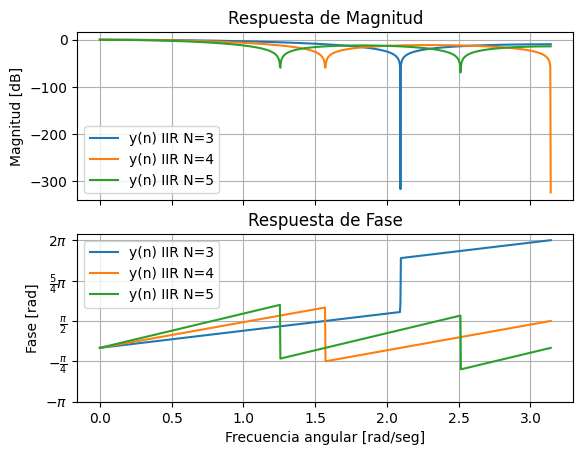

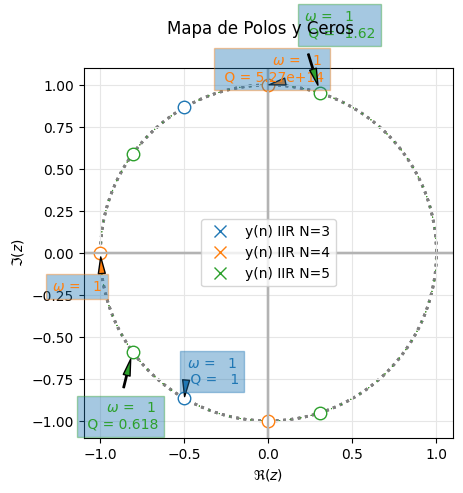

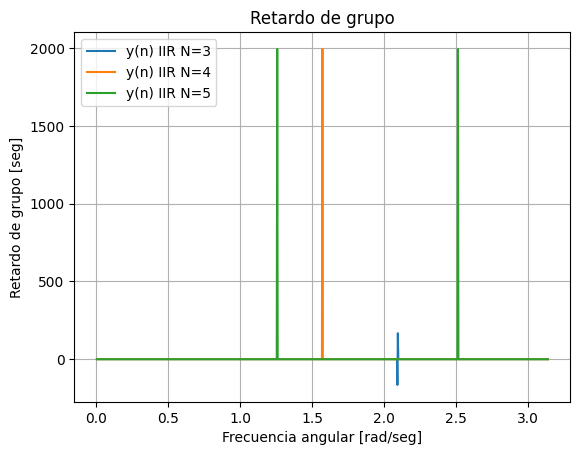

In [15]:
# ---- Parámetros del filtro no especificados los asumimos 0 ----
b1 = 0 
b2 = 0 
a2 = 0

# ---- Coeficientes de la transferencia ----
# N = 3:
num1 = np.array([1/3, 1/3, 1/3])
den1 = np.array([1])

# N = 4:
num2 = np.array([1/4, 1/4, 1/4, 1/4])
den2 = np.array([1])

# N = 5:
num3 = np.array([1/5, 1/5, 1/5, 1/5, 1/5])
den3 = np.array([1])

H1 = sig.TransferFunction(num1, den1, dt=1)  # sistema discreto
H2 = sig.TransferFunction(num2, den2, dt=1)
H3 = sig.TransferFunction(num3, den3, dt=1)

# ---- Análisis de la respuesta en frecuencia (módulo, fase, retardo, polos/ceros) ----
analyze_sys([H1], ['y(n) IIR N=3'])

analyze_sys([H2], ['y(n) IIR N=4'])

analyze_sys([H3], ['y(n) IIR N=5'])

plt.show()

## Filtro diferenciador
#### Tenemos que hallar los valores de los coeficientes para que se cumpla $y(n) = \frac{x(n) - x(n-2)}{2}$ :

#### Observando una de nuestras ecuaciones previas:
$$
Y(z) - Y(z)\, z^{-1} - Y(z)\, z^{-2}\, a_2 = X(z)\, \frac{1}{N}+X(z)\, z^{-1}\, b_1 +X(z)\, z^{-2}\, b_2 - X(z)\, z^{-N}\frac{1}{N}- X(z)\, z^{-N} z^{-1}\, b_1 - X(z)\, z^{-N} z^{-2}\, b_2
$$
#### Podemos deducir rápidamente que si sobreviven los términos con $\frac{1}{N}$ y cancelamos el resto nos queda:
$$
Y(z) = X(z)\, \frac{1}{N} - X(z)\, Z^{-N}\frac{1}{N}
$$
#### Pasando al dominio temporal nos queda:
$$
y(n) = \frac{1}{N} \cdot (x(n) - x(n-N))
$$
#### Y reemplazando $N=2$ se cumple que:
$$
y(n) = \frac{1}{2} \cdot (x(n) - x(n - 2))
$$

#### Por lo que los coeficientes quedan: $a_0=b_0=c_1=1$, $a_1=a_2=b_1=b_2=0$, $N=2$

### Analizamos ahora el comportamiento de este filtro FIR de orden 2 frente a la entrada senoidal pedida:

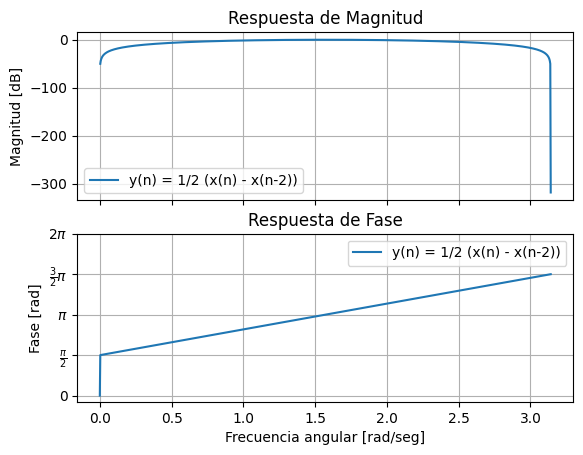

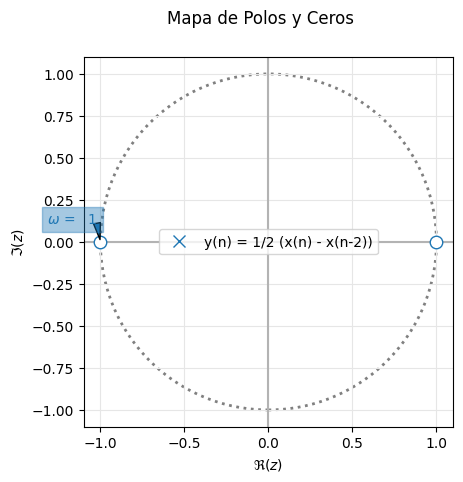

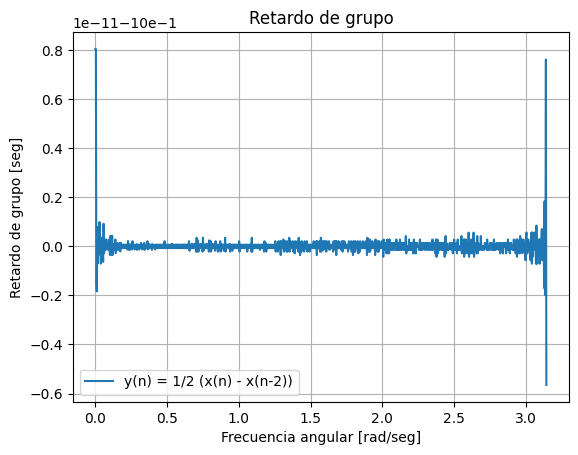

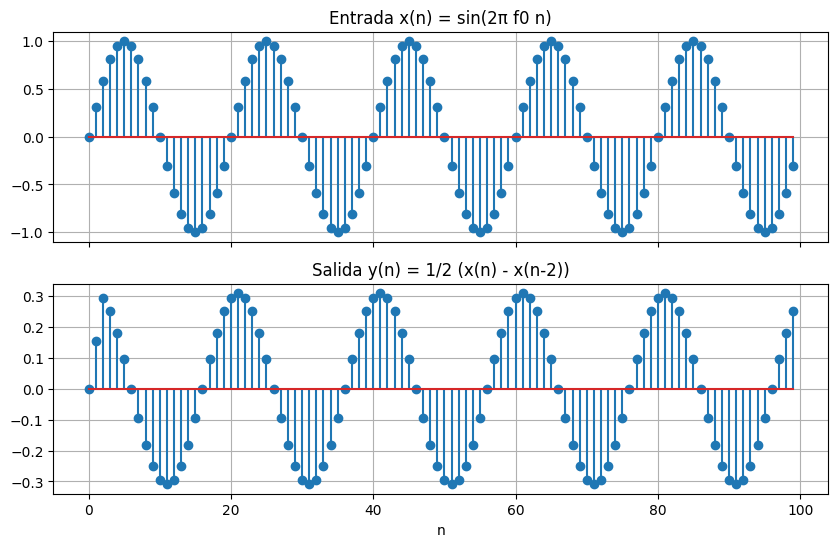

In [16]:
# ---- transferencia H(z) = 1/2 (1 - z^-2) ----
num = np.array([0.5, 0, -0.5])
den = np.array([1.0])

H = sig.TransferFunction(num, den, dt=1)  # dt=1 -> sistema discreto

# ---- respuesta en frecuencia (módulo, fase, retardo, polos/ceros) ----
analyze_sys([H], ['y(n) = 1/2 (x(n) - x(n-2))'])

# ---- Inyección de la señal senoidal discreta ----
N = 100
f0 = 0.05  # frecuencia normalizada
n = np.arange(N)
x = np.sin(2 * np.pi * f0 * n)

# Filtramos usando los mismos coeficientes num/den
y = sig.lfilter(num, den, x)

# ---- Gráficos de entrada y salida ----
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axs[0].stem(n, x)
axs[0].set_title("Entrada x(n) = sin(2π f0 n)")
axs[0].grid(True)

axs[1].stem(n, y)
axs[1].set_title("Salida y(n) = 1/2 (x(n) - x(n-2))")
axs[1].set_xlabel("n")
axs[1].grid(True)

#plt.tight_layout()
plt.show()

#### Sabiendo que la derivada del seno es un coseno, se puede verificar que la transferencia funciona gracias a los gráficos de entrada y salida

## Filtro Elimina continua:
#### Se nos pide verificar la transferencia ahora para $a_0=b_0=1$, $b_1=-1$, $a_1=\beta$, $\beta=0.9$
#### También se nos pide hallar $\beta$ para que la transferencia en $\Omega=0.1 \cdot \pi$ sea 3dB menor a $\Omega=\pi$

#### Reemplazamos los valores en la ecuación:
$$
H(z) = \frac{Y(z)}{X(z)}= \frac{1 - z^{-N} \cdot 0}{1 - z^{-1} \cdot 0.9 - z^{-2} \cdot 0}\cdot \big(1 + z^{-1} \cdot -1 + z^{-2} \cdot 0\big)
$$

$$
H(z) = \frac{Y(z)}{X(z)}= \frac{1}{1 - z^{-1} \cdot 0.9}\cdot \big(1 + z^{-1} \cdot -1\big)
$$

#### Lo simulamos:

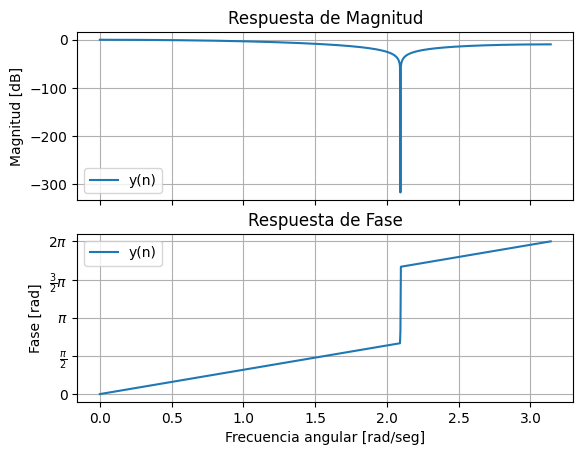

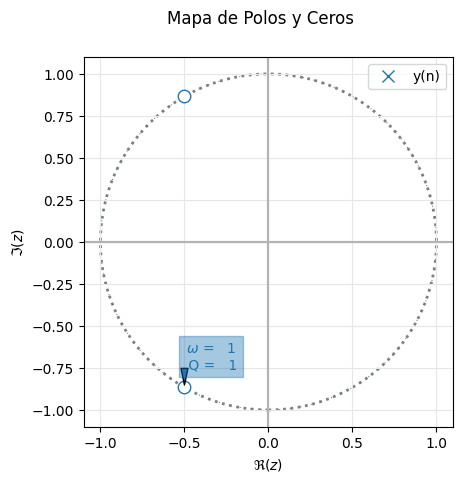

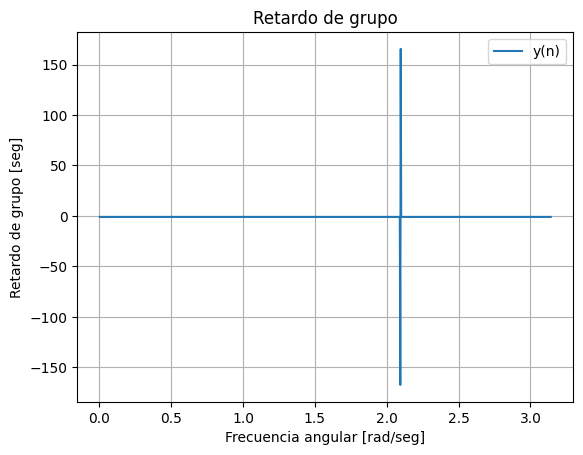

In [19]:
num = np.array([1, -1])
den = np.array([1, -0.9])

H = sig.TransferFunction(num, den, dt=1)  # sistema discreto

# ---- Análisis de la respuesta en frecuencia (módulo, fase, retardo, polos/ceros) ----
analyze_sys([H1], ['y(n)'])

plt.show()

## Buscamos ahora hallar $\beta$ mediante el hallazgo del módulo de la transferencia:

### Transferencia

$$H(z) = \frac{1-z^{-1}}{1-\beta\,z^{-1}}$$

### Hacemos el reemplazo $z=e^{j\Omega}$

**Numerador:**
$$1-e^{-j\Omega} = 2j\sin\!\left(\frac{\Omega}{2}\right)e^{-j\Omega/2} \;\Rightarrow\; \left|1-e^{-j\Omega}\right| = 2\left|\sin\!\left(\frac{\Omega}{2}\right)\right|$$

**Denominador:**
$$1-\beta e^{-j\Omega} = (1-\beta\cos\Omega)+j\beta\sin\Omega \;\Rightarrow\; \left|1-\beta e^{-j\Omega}\right| = \sqrt{1+\beta^2-2\beta\cos\Omega}$$

### Función módulo

$$\left|H(e^{j\Omega})\right| = \frac{2\left|\sin\!\left(\dfrac{\Omega}{2}\right)\right|}{\sqrt{1+\beta^2-2\beta\cos\Omega}}$$

---

## Planteo para hallar $\beta$

### Simplificación en $\Omega=\pi$

$$\left|H(e^{j\pi})\right| = \frac{2\sin(\pi/2)}{\sqrt{1+\beta^2+2\beta}} = \frac{2}{\sqrt{(1+\beta)^2}} = \frac{2}{1+\beta} \quad (\beta > -1)$$

### Condición de -3 dB

$$20\log_{10}\left|H(e^{j0.1\pi})\right| = 20\log_{10}\left|H(e^{j\pi})\right| - 3$$

$$\Rightarrow \left|H(e^{j0.1\pi})\right| = \left|H(e^{j\pi})\right|\cdot 10^{-3/20}$$

#### Elevo al cuadrado para simplificar:

$$\left|H(e^{j0.1\pi})\right|^2 = \left|H(e^{j\pi})\right|^2\cdot 10^{-3/10}$$

$$\frac{4\sin^2(0.05\pi)}{1+\beta^2-2\beta\cos(0.1\pi)} = 10^{-0.3}\cdot\frac{4}{(1+\beta)^2}$$

### Ecuación resultante en $\beta$

$$\sin^2(0.05\pi)\,(1+\beta)^2 = 10^{-0.3}\left(1+\beta^2-2\beta\cos(0.1\pi)\right)$$

$$\left[\sin^2(0.05\pi)-10^{-0.3}\right]\beta^2 + \left[2\sin^2(0.05\pi)+2\cdot10^{-0.3}\cos(0.1\pi)\right]\beta + \left[\sin^2(0.05\pi)-10^{-0.3}\right] = 0$$

#### Resolvemos numéricamente para simplificar las ecuaciones

Con $\sin^2(0.05\pi)\approx 0.024472$, $\cos(0.1\pi)\approx 0.951057$, $10^{-0.3}\approx 0.501187$:

$$-0.476715\,\beta^2 + 1.002258\,\beta - 0.476715 = 0 \quad\Longrightarrow\quad \beta^2 - 2.102176\,\beta + 1 = 0$$

$$\beta = \frac{2.102176 \pm \sqrt{2.102176^2-4}}{2} = \frac{2.102176\pm0.647412}{2}$$

$$\beta_1 \approx 1.3748 \qquad \beta_2 \approx 0.7274$$

Para que el sistema sea estable, el polo (en $z=\beta$) debe estar dentro del círculo unitario: $|\beta|<1$. Entonces elegimos $\beta_2$ que cumple esto y listo, nos queda:

$$\beta \approx 0.7274$$

## Filtro Peine:
#### Ahora tenemos que verificar la transferencia para $c_1 = -1$ y $N=8$
#### luego tendremos que proponer una $f_{sampling}$ para ver dónde se generan los "peaks" y "nulls" en el espectro

$$
H(z) = \frac{Y(z)}{X(z)}= \frac{1 - z^{-8} \cdot -1}{1 - z^{-1} \cdot 0 - z^{-2} \cdot 0}\cdot \big(1 + z^{-1} \cdot 0 + z^{-2} \cdot 0\big)
$$

$$
H(z) = \frac{Y(z)}{X(z)}= \frac{1 + z^{-8}}{1}\cdot \big(1 \big)
$$

#### Primero tenemos que ver la función módulo para predecir dónde estarán los "peaks" y "nulls" :

## Filtro peine: $H(z) = 1+z^{-8}$

### Función módulo

Evaluando en $z=e^{j\Omega}$:

$$H(e^{j\Omega}) = 1+e^{-j8\Omega}$$

Sacando factor de fase común:

$$1+e^{-j8\Omega} = e^{-j4\Omega}\left(e^{j4\Omega}+e^{-j4\Omega}\right) = 2\cos(4\Omega)\,e^{-j4\Omega}$$

$$\left|H(e^{j\Omega})\right| = 2\left|\cos(4\Omega)\right|$$

### Esto nos deja claro que tendremos picos en H = 2 y nulos en H = 0:

**Picos** ($|H|=2$):
$$\cos(4\Omega)=\pm1 \;\Rightarrow\; \Omega = \frac{k\pi}{4}$$

**Nulos** ($|H|=0$):
$$\cos(4\Omega)=0 \;\Rightarrow\; \Omega = \frac{\pi}{8}+\frac{k\pi}{4}$$


### Pasamos a frecuencia física

$$\Omega = \frac{2\pi f}{f_s} \quad\Longrightarrow\quad f = \frac{\Omega\, f_s}{2\pi}$$

**Picos:**
#### Reemplazo $\Omega$ por $\frac{k\pi}{4}$ y nos queda:
$$f_{\text{picos}} = \frac{f_s}{8}\,k \,,\quad k=0,1,2,3,4 \;\Rightarrow\; f = 0,\ \frac{f_s}{8},\ \frac{f_s}{4},\ \frac{3f_s}{8},\ \frac{f_s}{2}$$

**Nulos:**
#### Reemplazo $\Omega = \frac{\pi}{8}+\frac{k\pi}{4}$ :
$$f_{\text{nulos}} = \frac{f_s}{16} + \frac{f_s}{8}\,k \,,\quad k=0,1,2,3 \;\Rightarrow\; f = \frac{f_s}{16},\ \frac{3f_s}{16},\ \frac{5f_s}{16},\ \frac{7f_s}{16}$$

La elección entonces de $f_s$ será aquella que me convenga mejor sabiendo que el peine escala con potencias de 2 en 8. Elegimos entonces arbitrariamente f = 8000Hz

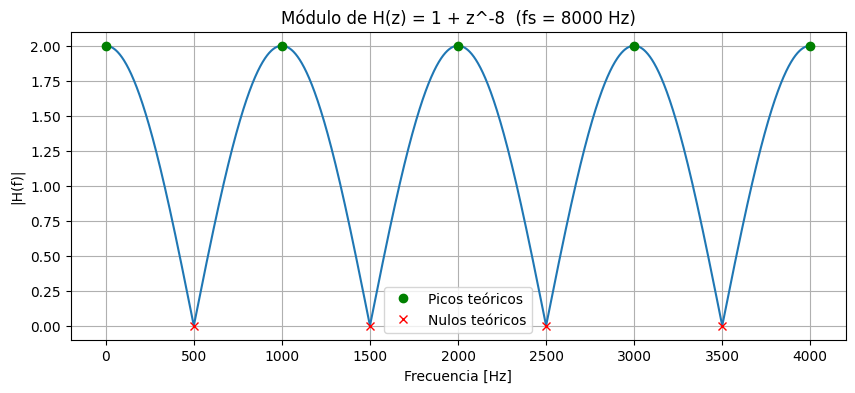

In [21]:
N = 8
num = np.zeros(N + 1)
num[0] = 1
num[N] = 1
den = np.array([1])

fs = 8000  # elijo

w, H = sig.freqz(num, den, worN=2048, fs=fs)

mod = np.abs(H)

plt.figure(figsize=(10, 4))
plt.plot(w, mod)
plt.title(f"Módulo de H(z) = 1 + z^-{N}  (fs = {fs} Hz)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|H(f)|")
plt.grid(True)

# Marcarmos picos y nulos teóricos
picos = np.array([0, fs/8, fs/4, 3*fs/8, fs/2])
nulos = np.array([fs/16, 3*fs/16, 5*fs/16, 7*fs/16])
plt.plot(picos, 2*np.ones_like(picos), 'go', label='Picos teóricos')
plt.plot(nulos, np.zeros_like(nulos), 'rx', label='Nulos teóricos')
plt.legend()
plt.show()

## Diagrama en Bloques de los filtros:
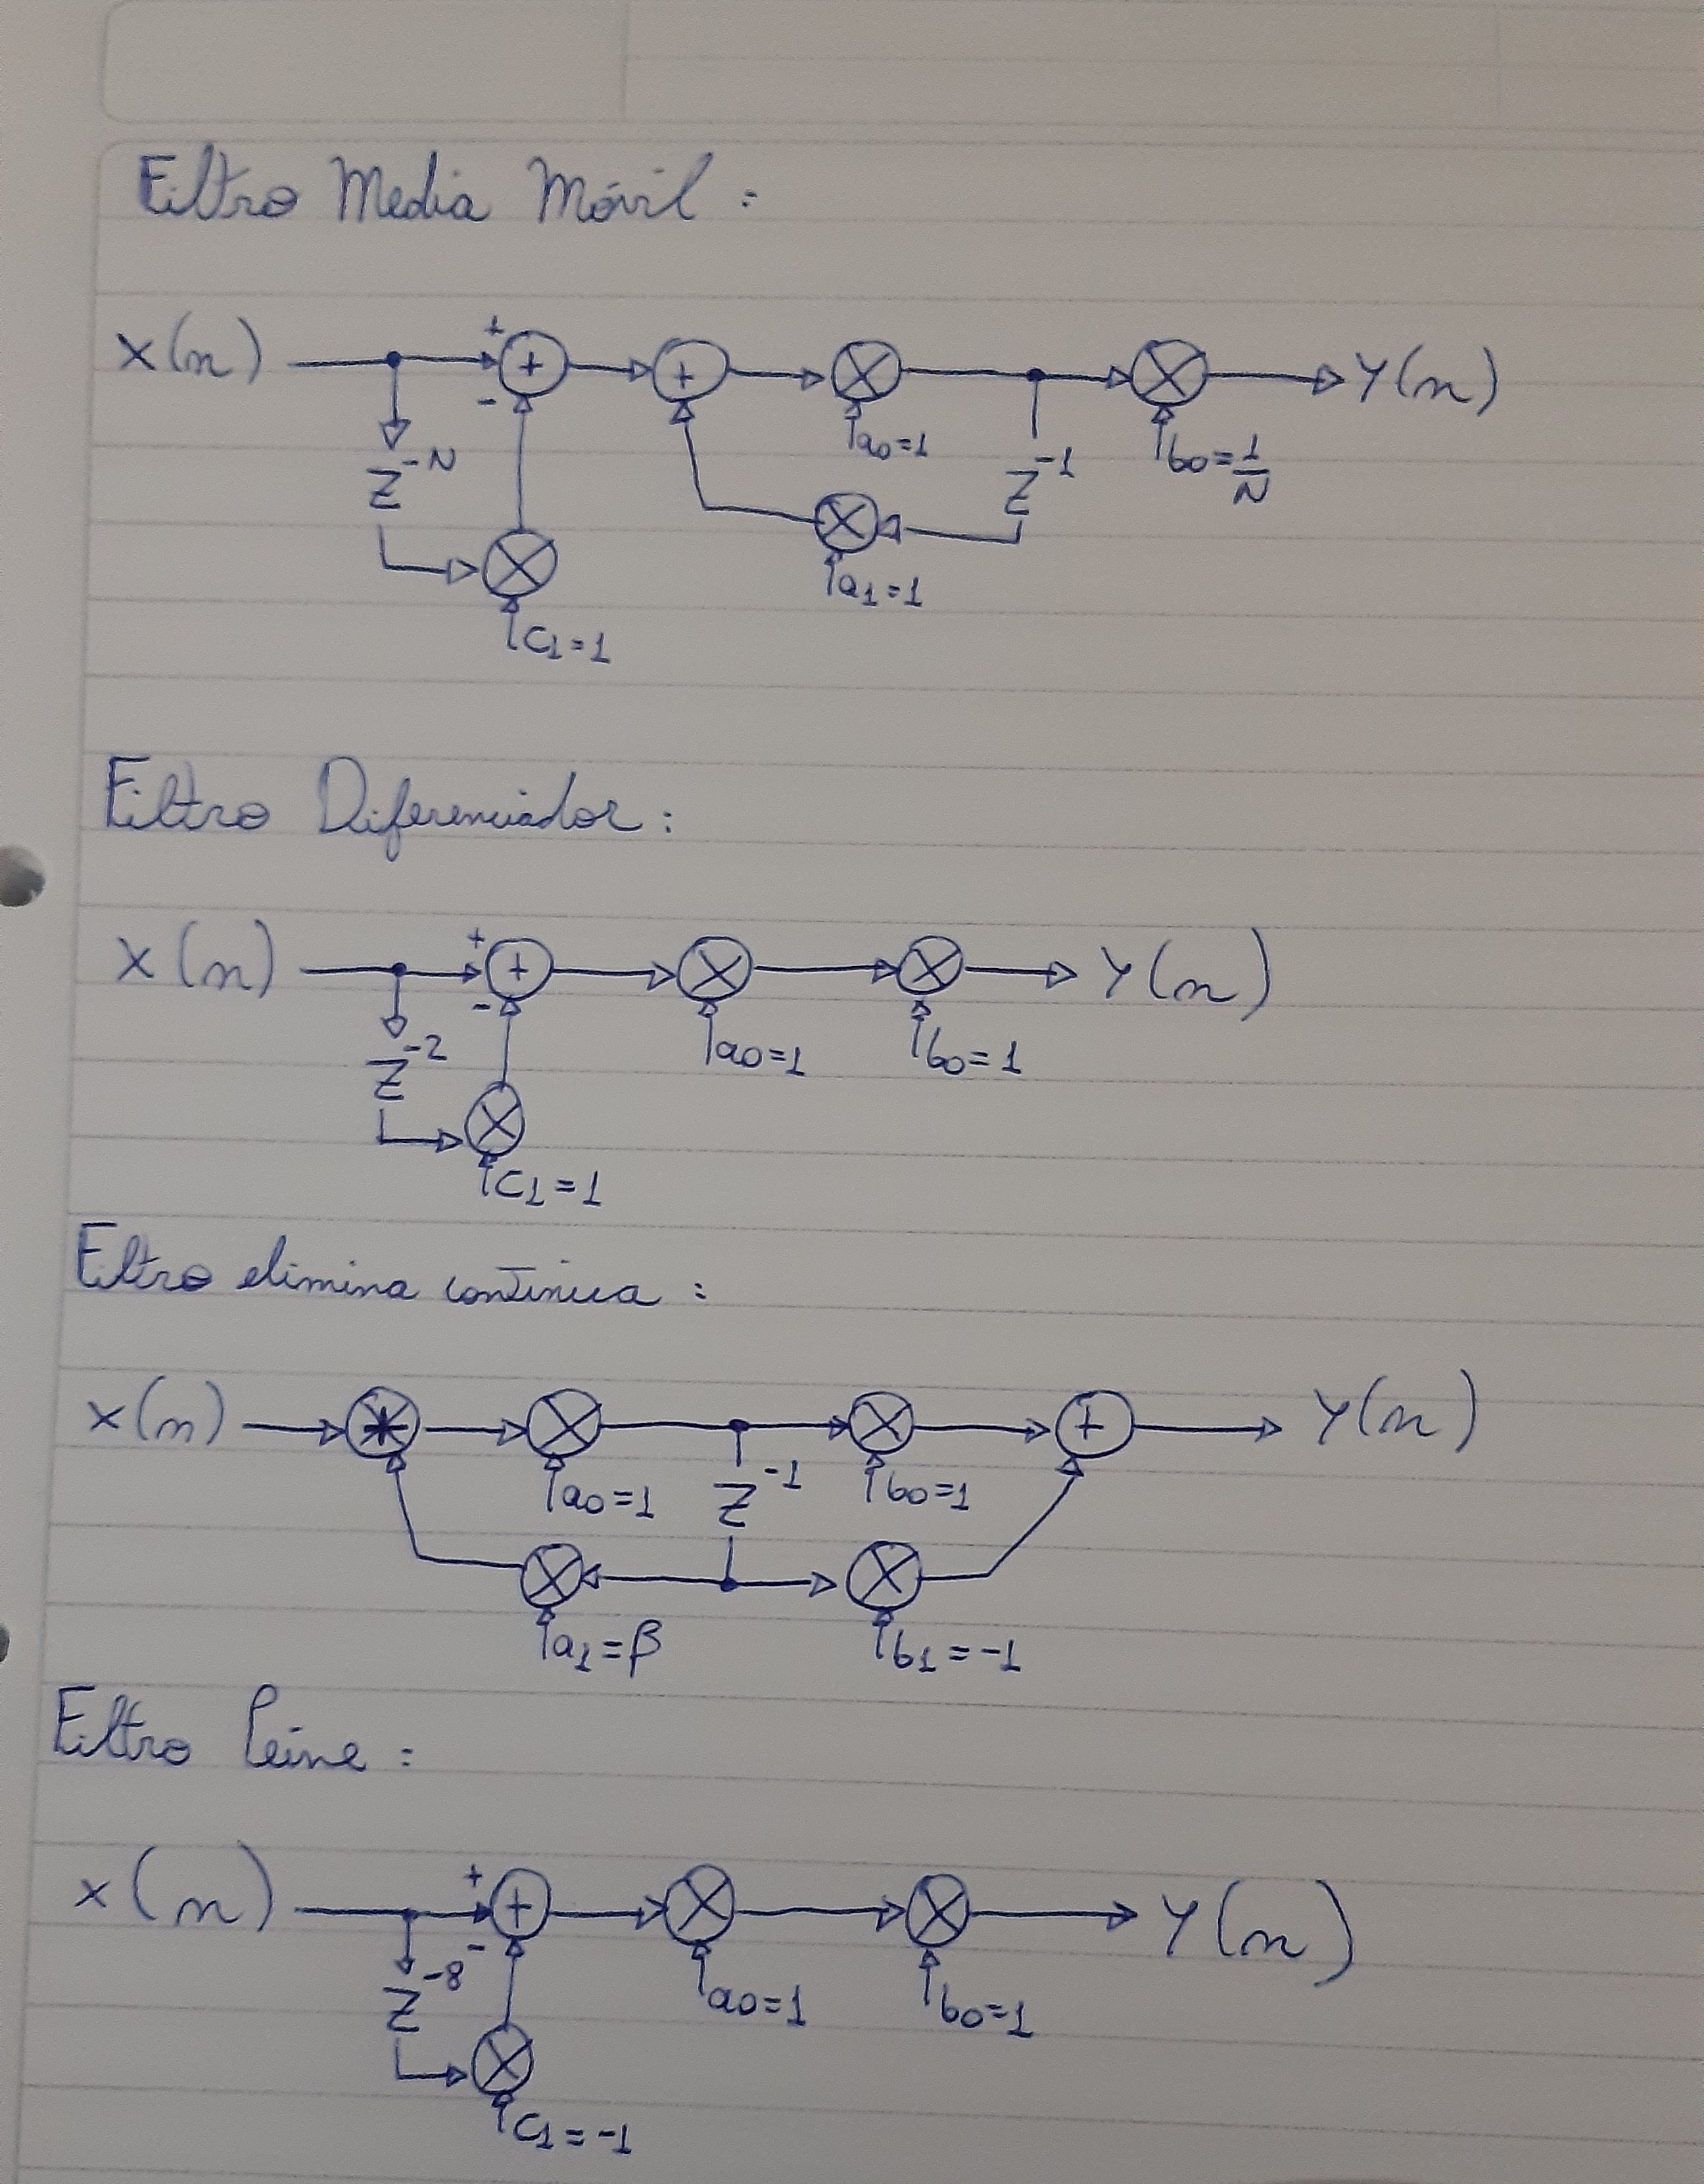